In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

import numpy as np
import os
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import requests

from sklearn.model_selection import cross_val_score, cross_validate, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

import joblib

In [ ]:
# import parquet file from ../datasets/processed/
# master_data = pd.read_parquet('../datasets/processed/master_data.parquet')
# master_data_dropped = pd.read_parquet('../datasets/processed/master_data_dropped.parquet')
# master_data_imputed = pd.read_parquet('../datasets/processed/master_data_imputed.parquet')


In [2]:
# Set to True to download data from GitHub, False to load from local processed directory
DOWNLOAD = True

if DOWNLOAD:
    # Download CSV files from GitHub repository
    directory = "./downloads/"
    filenames = [
        "master_data.parquet",
        "master_data_dropped.parquet",
        "master_data_imputed.parquet"
    ]

    # Common URL parts
    base_url = "https://github.com/fbec76/sas-curiosity-cup-2026/raw/refs/heads/main/datasets/processed/"
    for fname in filenames:
        url = base_url + fname + "?download="
        response = requests.get(url)
        if response.ok:

            if not os.path.exists(directory):
                os.makedirs(directory)
            with open(directory + fname, "wb") as f:
                f.write(response.content)
            print(f"Downloaded: {fname}")
        else:
            print(f"Failed to download: {fname}")
    data_dir = "./downloads/"
    # master_data_orig = pd.read_parquet(data_dir + "master_data.parquet")
    master_data_dropped_orig = pd.read_parquet(data_dir + "master_data_dropped.parquet")
    master_data_imputed_orig = pd.read_parquet(data_dir + "master_data_imputed.parquet")
    print("Data loaded from downloads directory.")
else:
    # master_data_orig = pd.read_parquet("../datasets/processed/master_data.parquet")
    master_data_dropped_orig = pd.read_parquet("../datasets/processed/master_data_dropped.parquet")
    master_data_imputed_orig = pd.read_parquet("../datasets/processed/master_data_imputed.parquet")
    data_dir = "../datasets/processed/"
    print("Data loaded from processed directory.")


Downloaded: master_data.parquet
Downloaded: master_data_dropped.parquet
Downloaded: master_data_imputed.parquet
Data loaded from downloads directory.


In [3]:
# master_data = master_data_orig.copy()
master_data_dropped = master_data_dropped_orig.copy()
master_data_imputed = master_data_imputed_orig.copy()

In [ ]:
master_data_dropped.shape

In [4]:
# check the shape of the dataframes
# print('master_data shape:', master_data.shape, "Count of NA values:", master_data.isna().sum().sum())
print('master_data_dropped shape:', master_data_dropped.shape, "Count of NA values:", master_data_dropped.isna().sum().sum())
print('master_data_imputed shape:', master_data_imputed.shape, "Count of NA values:", master_data_imputed.isna().sum().sum())

master_data_dropped shape: (2594574, 40) Count of NA values: 0
master_data_imputed shape: (4450350, 35) Count of NA values: 0


In [ ]:
master_data_dropped.head()

In [5]:
# drop unwanted identifier/name/date columns and convert any date-like columns to numeric timestamps
cols_to_drop = ['GAME_DATE', 'TEAM_ID', 'GAME_ID', 'PLAYER_NAME', 'PLAYER_ID', 'LAT', 'LON', 'D_LAT', 'D_LON', 'GAME_DATE', 'IS_3PT', 'DISTANNCE_KM', 'TZ_SHIFT', 'HOME_TEAM', 'AWAY_TEAM', 'TEAM_NAME']
cols_present_to_drop = [c for c in cols_to_drop if c in master_data_dropped.columns]
if cols_present_to_drop:
    master_data_dropped.drop(columns=cols_present_to_drop, inplace=True)
    master_data_imputed.drop(columns=cols_present_to_drop, inplace=True)



In [ ]:
master_data_dropped.head(2)

In [6]:

# Create FLIGHT_TIME_MIN buckets using fixed thresholds (interpretable, consistent)
col = 'FLIGHT_TIME_MIN'
if col not in master_data_dropped.columns:
    raise KeyError(f"Column {col} not found in master_data_dropped")

s = master_data_dropped[col].dropna()
print('FLIGHT_TIME_MIN: count, min, median, mean, max ->', s.shape[0], s.min(), s.median(), s.mean(), s.max())

# Fixed thresholds (interpretable and consistent across train/test splits)
# Thresholds: <=1h short, 1-3h medium, 3-6h long, >6h very_long
thresholds_minutes = [60, 180, 360]
bins_fixed = [-float('inf')] + thresholds_minutes + [float('inf')]
labels_fixed = ['short', 'medium', 'long', 'very_long']
master_data_dropped['FLIGHT_TIME_BUCKET'] = pd.cut(master_data_dropped[col], bins=bins_fixed, labels=labels_fixed)

print('\nFixed minute thresholds:', thresholds_minutes)
print('Value counts (flight buckets):')
print(master_data_dropped['FLIGHT_TIME_BUCKET'].value_counts(dropna=False))


continuous_features = [
    "BODY_FAT_PCT",
    "DISTANCE_KM",
    "HAND_LENGTH_CM",
    "HAND_WIDTH_CM",
    "HEIGHT_CM",
    "LANE_AGILITY_TIME_S",
    "LOC_X_CM",
    "LOC_Y_CM",
    "MAX_VERTICAL_LEAP_CM",
    "REST_D",
    "SEASON",  # normalize to allow learning an overall trend
    "SHOT_DISTANCE_CM",
    "STANDING_REACH_CM",
    "STANDING_VERTICAL_LEAP_CM",
    "THREE_QUARTER_SPRINT_S",
    "TIME_LEFT_S",
    "TZ_SHIFT",
    "WEIGHT_KG",
    "WINGSPAN_CM"
]
# Standardize only the specified continuous features (if present)
cont_feats = [c for c in continuous_features if c in master_data_dropped.columns]
if cont_feats:
    scaler_cont = StandardScaler()
    master_data_dropped[cont_feats] = scaler_cont.fit_transform(master_data_dropped[cont_feats])

# Create a copy to avoid modifying original; keep all categorical columns as-is (no one-hot / label encoding)
master_data_dropped_normalised = master_data_dropped.copy()

# Identify numerical columns (excluding identifiers and already-normalized continuous features)
numerical_cols = master_data_dropped.select_dtypes(include=['float64', 'int64']).columns.tolist()


# One-hot encode FLIGHT_TIME_BUCKET column
master_data_dropped_normalised = pd.get_dummies(
    master_data_dropped_normalised,
    columns=['FLIGHT_TIME_BUCKET'],
    prefix='FLIGHT_TIME_BUCKET',
    drop_first=False  # Keep all categories (change to True to avoid multicollinearity)
)
master_data_dropped_normalised.drop(columns=['FLIGHT_TIME_BUCKET_very_long'], inplace=True)

print("One-hot encoding complete!")
print("New columns:")
print(master_data_dropped_normalised.columns.tolist())


print("Normalization complete!")
print(f"Continuous features standardized: {cont_feats}")


FLIGHT_TIME_MIN: count, min, median, mean, max -> 2594574 0.0 55.0 64.36146501506612 298.2

Fixed minute thresholds: [60, 180, 360]
Value counts (flight buckets):
FLIGHT_TIME_BUCKET
short        1496042
medium        979033
long          119499
very_long          0
Name: count, dtype: int64
One-hot encoding complete!
New columns:
['SEASON', 'QUARTER', 'TIME_LEFT_S', 'LOC_X_CM', 'LOC_Y_CM', 'SHOT_DISTANCE_CM', 'DISTANCE_KM', 'REST_D', 'FLIGHT_TIME_MIN', 'HEIGHT_CM', 'WEIGHT_KG', 'WINGSPAN_CM', 'STANDING_REACH_CM', 'HAND_LENGTH_CM', 'HAND_WIDTH_CM', 'BODY_FAT_PCT', 'LANE_AGILITY_TIME_S', 'THREE_QUARTER_SPRINT_S', 'MAX_VERTICAL_LEAP_CM', 'STANDING_VERTICAL_LEAP_CM', 'POS_PG', 'POS_SG', 'POS_SF', 'POS_PF', 'POS_C', 'MADE_SHOT', 'FLIGHT_TIME_BUCKET_short', 'FLIGHT_TIME_BUCKET_medium', 'FLIGHT_TIME_BUCKET_long']
Normalization complete!
Continuous features standardized: ['BODY_FAT_PCT', 'DISTANCE_KM', 'HAND_LENGTH_CM', 'HAND_WIDTH_CM', 'HEIGHT_CM', 'LANE_AGILITY_TIME_S', 'LOC_X_CM', 'LOC_Y_CM

In [7]:

# Create FLIGHT_TIME_MIN buckets using fixed thresholds (interpretable, consistent)
col = 'FLIGHT_TIME_MIN'
if col not in master_data_imputed.columns:
    raise KeyError(f"Column {col} not found in master_data_imputed")

s = master_data_imputed[col].dropna()
print('FLIGHT_TIME_MIN: count, min, median, mean, max ->', s.shape[0], s.min(), s.median(), s.mean(), s.max())

# Fixed thresholds (interpretable and consistent across train/test splits)
# Thresholds: <=1h short, 1-3h medium, 3-6h long, >6h very_long
thresholds_minutes = [60, 180, 360]
bins_fixed = [-float('inf')] + thresholds_minutes + [float('inf')]
labels_fixed = ['short', 'medium', 'long', 'very_long']
master_data_imputed['FLIGHT_TIME_BUCKET'] = pd.cut(master_data_imputed[col], bins=bins_fixed, labels=labels_fixed)

print('\nFixed minute thresholds:', thresholds_minutes)
print('Value counts (flight buckets):')
print(master_data_imputed['FLIGHT_TIME_BUCKET'].value_counts(dropna=False))


continuous_features = [
    "BODY_FAT_PCT",
    "DISTANCE_KM",
    "HAND_LENGTH_CM",
    "HAND_WIDTH_CM",
    "HEIGHT_CM",
    "LANE_AGILITY_TIME_S",
    "LOC_X_CM",
    "LOC_Y_CM",
    "MAX_VERTICAL_LEAP_CM",
    "REST_D",
    "SEASON",  # normalize to allow learning an overall trend
    "SHOT_DISTANCE_CM",
    "STANDING_REACH_CM",
    "STANDING_VERTICAL_LEAP_CM",
    "THREE_QUARTER_SPRINT_S",
    "TIME_LEFT_S",
    "TZ_SHIFT",
    "WEIGHT_KG",
    "WINGSPAN_CM"
]
# Standardize only the specified continuous features (if present)
cont_feats = [c for c in continuous_features if c in master_data_imputed.columns]
if cont_feats:
    scaler_cont = StandardScaler()
    master_data_imputed[cont_feats] = scaler_cont.fit_transform(master_data_imputed[cont_feats])

# Create a copy to avoid modifying original; keep all categorical columns as-is (no one-hot / label encoding)
master_data_imputed_normalised = master_data_imputed.copy()

# Identify numerical columns (excluding identifiers and already-normalized continuous features)
numerical_cols = master_data_imputed.select_dtypes(include=['float64', 'int64']).columns.tolist()


# One-hot encode FLIGHT_TIME_BUCKET column
master_data_imputed_normalised = pd.get_dummies(
    master_data_imputed_normalised,
    columns=['FLIGHT_TIME_BUCKET'],
    prefix='FLIGHT_TIME_BUCKET',
    drop_first=False  # Keep all categories (change to True to avoid multicollinearity)
)
master_data_imputed_normalised.drop(columns=['FLIGHT_TIME_BUCKET_very_long'], inplace=True)

print("One-hot encoding complete!")
print("New columns:")
print(master_data_imputed_normalised.columns.tolist())


print("Normalization complete!")
print(f"Continuous features standardized: {cont_feats}")


FLIGHT_TIME_MIN: count, min, median, mean, max -> 4450350 0.0 55.0 64.79344542564068 298.2

Fixed minute thresholds: [60, 180, 360]
Value counts (flight buckets):
FLIGHT_TIME_BUCKET
short        2551430
medium       1692654
long          206266
very_long          0
Name: count, dtype: int64
One-hot encoding complete!
New columns:
['SEASON', 'QUARTER', 'TIME_LEFT_S', 'LOC_X_CM', 'LOC_Y_CM', 'SHOT_DISTANCE_CM', 'DISTANCE_KM', 'REST_D', 'FLIGHT_TIME_MIN', 'HEIGHT_CM', 'WEIGHT_KG', 'WINGSPAN_CM', 'STANDING_REACH_CM', 'HAND_LENGTH_CM', 'HAND_WIDTH_CM', 'BODY_FAT_PCT', 'LANE_AGILITY_TIME_S', 'THREE_QUARTER_SPRINT_S', 'MAX_VERTICAL_LEAP_CM', 'STANDING_VERTICAL_LEAP_CM', 'MADE_SHOT', 'FLIGHT_TIME_BUCKET_short', 'FLIGHT_TIME_BUCKET_medium', 'FLIGHT_TIME_BUCKET_long']
Normalization complete!
Continuous features standardized: ['BODY_FAT_PCT', 'DISTANCE_KM', 'HAND_LENGTH_CM', 'HAND_WIDTH_CM', 'HEIGHT_CM', 'LANE_AGILITY_TIME_S', 'LOC_X_CM', 'LOC_Y_CM', 'MAX_VERTICAL_LEAP_CM', 'REST_D', 'SEASON', 'S

In [ ]:
master_data_dropped_normalised.columns

In [10]:
master_data_dropped.head(2)

In [11]:
master_data_dropped_normalised.head()

In [12]:
master_data_imputed_normalised.head()

In [ ]:
# # Build decision tree models with cross validation
# # Use MADE_SHOT as target
# X = master_data_dropped_encoded.drop(columns=['MADE_SHOT'])
# y = master_data_dropped_encoded['MADE_SHOT'].astype(int)

# dt_model = DecisionTreeClassifier(random_state=42)

# cv_results = cross_validate(
#     dt_model, X, y, cv=5,
#     scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
#     return_train_score=True
# )

# print("master_data_dropped (target=MADE_SHOT):")
# print(f"  Accuracy: {cv_results['test_accuracy'].mean():.4f} (+/- {cv_results['test_accuracy'].std():.4f})")
# print(f"  Precision: {cv_results['test_precision_weighted'].mean():.4f}")
# print(f"  Recall: {cv_results['test_recall_weighted'].mean():.4f}")
# print(f"  F1-Score: {cv_results['test_f1_weighted'].mean():.4f}")


In [ ]:
'''# drop unwanted identifier/name/date columns and convert any date-like columns to numeric timestamps
cols_to_drop = ['GAME_DATE', 'TEAM_ID', 'GAME_ID', 'PLAYER_NAME', 'PLAYER_ID', 'REST_D']
cols_present_to_drop = [c for c in cols_to_drop if c in master_data_dropped_normalised.columns]
if cols_present_to_drop:
    master_data_dropped_normalised.drop(columns=cols_present_to_drop, inplace=True)

# detect and fix date-like columns: parse to datetime, then convert to integer timestamp (seconds since epoch)
date_cols_fixed = []
for col in master_data_dropped_normalised.columns:
    # only try parsing object or datetime-like dtypes
    if master_data_dropped_normalised[col].dtype == 'object' or np.issubdtype(master_data_dropped_normalised[col].dtype, np.datetime64):
        parsed = pd.to_datetime(master_data_dropped_normalised[col], errors='coerce', infer_datetime_format=True)
        # consider it a date column if a reasonable fraction parsed successfully
        if parsed.notna().mean() > 0.5:
            # convert to seconds since epoch as integer (suitable for sklearn)
            master_data_dropped_normalised[col] = parsed.astype('datetime64[ns]').astype('int64') // 10**9
            date_cols_fixed.append(col)

print(f"Dropped columns: {cols_present_to_drop}")
print(f"Converted date-like columns to numeric timestamps: {date_cols_fixed}")'''

In [ ]:
master_data_dropped.head()

In [ ]:
master_data_dropped['QUARTER'].value_counts()

In [ ]:
master_data_dropped_normalised.head()

In [ ]:
# X = master_data_dropped_normalised.drop(columns=['MADE_SHOT'])
# y = master_data_dropped_normalised['MADE_SHOT'].astype(int)

In [ ]:
'''def _fit_linear_classifier(
        df,
        target,
        features_list,
        cv_folds=5,
        scoring="f1",
        model_type="logreg",  # "logreg" or "sgd"
        penalty_type="lasso",  # "lasso" or "ridge"
        sgd_max_iter=2000,
        sgd_tol=1e-3,
):
    X = df[features_list]
    y = df[target]

    start_time = pd.Timestamp.now()

    if model_type == "logreg":
        # Keep your current setup: LogisticRegression with elasticnet via saga
        l1_ratio = 1.0 if penalty_type == "lasso" else 0.0
        model = LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=l1_ratio,
            max_iter=10000,
        )
        param_grid = {"C": [0.01, 0.1, 1, 10, 100]}

    elif model_type == "sgd":
        # SGDClassifier approximates logistic regression when loss='log_loss'
        # Regularization strength is controlled by alpha (roughly inverse of C).
        penalty = "l1" if penalty_type == "lasso" else "l2"
        model = SGDClassifier(
            loss="log_loss",
            penalty=penalty,
            max_iter=sgd_max_iter,
            tol=sgd_tol,
            random_state=42,
        )
        param_grid = {"alpha": [1e-2, 1e-3, 1e-4, 1e-5]}

    else:
        raise ValueError("model_type must be 'logreg' or 'sgd'")

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv_folds,
        scoring=scoring,
        n_jobs=-1,
    )
    grid_search.fit(X, y)

    best_model = grid_search.best_estimator_

    y_pred_cv = cross_val_predict(best_model, X, y, cv=cv_folds, n_jobs=-1)

    print("Best Hyperparameters:", grid_search.best_params_)
    print("Classification Report (CV preds):\n", classification_report(y, y_pred_cv))
    print("Confusion Matrix (CV preds):\n", confusion_matrix(y, y_pred_cv))
    print("Time taken:", pd.Timestamp.now() - start_time)

    return best_model


def lasso_logistic_regression(df, target, features_list, cv_folds=5, model_type="logreg", scoring="f1"):
    return _fit_linear_classifier(
        df=df,
        target=target,
        features_list=features_list,
        cv_folds=cv_folds,
        scoring=scoring,
        model_type=model_type,
        penalty_type="lasso",
    )


def ridge_logistic_regression(df, target, features_list, cv_folds=5, model_type="logreg", scoring="f1"):
    return _fit_linear_classifier(
        df=df,
        target=target,
        features_list=features_list,
        cv_folds=cv_folds,
        scoring=scoring,
        model_type=model_type,
        penalty_type="ridge",
    )'''

In [ ]:
'''
param_dist = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 2, 4, 8, 16],
    'max_leaf_nodes': [None, 5, 10, 20, 50, 100],
    'min_impurity_decrease': [0.0, 1e-5, 1e-4, 1e-3],
    'ccp_alpha': [0.0, 1e-5, 1e-4, 1e-3]
}

dt = DecisionTreeClassifier(random_state=42)

rs = RandomizedSearchCV(
    dt,
    param_distributions=param_dist,
    n_iter=50,                # number of parameter settings sampled
    scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
    refit='f1_weighted',      # choose best model by weighted F1
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rs.fit(X, y)

print("Best params:")
print(rs.best_params_)
print(f"Best {rs.refit} (cv): {rs.best_score_:.4f}")

# show top 5 candidates by chosen refit score
results = pd.DataFrame(rs.cv_results_).sort_values('rank_test_f1_weighted')
display(results[['params', 'mean_test_f1_weighted', 'std_test_f1_weighted', 'rank_test_f1_weighted']].head())
# optionally save best model
joblib.dump(rs.best_estimator_, 'best_dt_model.joblib')
'''

In [ ]:
master_data_dropped_normalised.head()

In [ ]:
master_data_dropped.columns

### PCA

In [7]:
def perform_pca(df, features_list, variance_threshold=0.9):
    X = df[features_list]
    pca = PCA(n_components=variance_threshold, random_state=42)
    X_pca = pca.fit_transform(X)
    n_components = X_pca.shape[1]
    print(f"PCA reduced {len(features_list)} features to {n_components} components to retain {variance_threshold*100}% variance.")
    print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
    print(f"Cumulative explained variance: {np.cumsum(pca.explained_variance_ratio_)}")
    return X_pca


In [15]:
features_list_dropped = master_data_dropped.drop(columns=['MADE_SHOT', 'FLIGHT_TIME_BUCKET']).columns.tolist()
pca_dropped= perform_pca(master_data_dropped, features_list_dropped)

In [9]:
features_list_dropped_normalised = master_data_dropped_normalised.drop(columns=['MADE_SHOT']).columns.tolist()

pca_dropped= perform_pca(master_data_dropped_normalised, features_list_dropped_normalised)

In [ ]:
len(features_list_dropped)

In [ ]:
pca_dropped[1]

In [ ]:
'''from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

def perform_pca_pipeline(df, features_list, variance_threshold=0.9):
    X = df[features_list]

    # Split by dtype
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = X.select_dtypes(include=['number', 'bool']).columns.tolist()

    # Transformers
    numeric_tf = Pipeline(steps=[
        ('scaler', StandardScaler(with_mean=True, with_std=True))
    ])

    categorical_tf = Pipeline(steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_tf, num_cols),
            ('cat', categorical_tf, cat_cols),
        ],
        remainder='drop'
    )

    # NOTE: random_state only applies when svd_solver='randomized'
    pca = PCA(n_components=variance_threshold, svd_solver='full')

    pipe = Pipeline(steps=[
        ('prep', preprocessor),
        ('pca', pca)
    ])

    X_pca = pipe.fit_transform(X)
    n_components = X_pca.shape[1]
    evr = pipe.named_steps['pca'].explained_variance_ratio_
    print(f"PCA reduced {len(features_list)} features to {n_components} components to retain {variance_threshold*100:.1f}% variance.")
    print(f"Explained variance ratio: {evr}")
    print(f"Cumulative explained variance: {evr.cumsum()}")

    return pipe, X_pca  # return the fitted pipeline so you can transform new data consistently


features_list_dropped = master_data_dropped.drop(columns=['MADE_SHOT']).columns.tolist()

pipe, X_pca = perform_pca_pipeline(master_data_dropped, features_list_dropped, variance_threshold=0.9)

# PC1 scores for each row
pc1_scores = X_pca[:, 0]'''
    

In [16]:
master_data_dropped_normalised.shape

### Dec Tree

In [8]:
def _fit_decision_tree_classifier(
        df,
        target,
        features_list,
        cv_folds=3,
        scoring="f1_weighted",
        n_iter=15,
        param_dist=None,
):
    """
    Fit a Decision Tree classifier with hyperparameter tuning via RandomizedSearchCV.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The input dataframe containing features and target
    target : str
        Column name of the target variable
    features_list : list
        List of feature column names to use
    cv_folds : int
        Number of cross-validation folds (default: 5)
    scoring : str
        Primary scoring metric for model selection (default: 'f1_weighted')
    n_iter : int
        Number of parameter settings sampled in RandomizedSearchCV (default: 50)
    param_dist : dict
        Parameter distribution for RandomizedSearchCV. If None, uses defaults.
    
    Returns:
    --------
    best_model : DecisionTreeClassifier
        The best fitted decision tree model
    """
    X = df[features_list]
    y = df[target]

    start_time = pd.Timestamp.now()

    if param_dist is None:
        '''param_dist = {
            'criterion': ['gini', 'entropy'],
            'max_depth': [None, 5, 10, 20, 30],
            'min_samples_split': [2, 5, 10, 20, 50],
            'min_samples_leaf': [1, 2, 4, 8, 16],
            'max_leaf_nodes': [None, 5, 10, 20, 50, 100],
            'min_impurity_decrease': [0.0, 1e-5, 1e-4, 1e-3],
            'ccp_alpha': [0.0, 1e-5, 1e-4, 1e-3]
        }'''
        
        '''param_dist = {
            'criterion': ['gini'],   # 'entropy' is slower
            'max_depth': [5, 10, 20, None],
            'min_samples_split': [2, 10, 20],
            'min_samples_leaf': [1, 2, 4],
            'max_leaf_nodes': [None, 10, 20, 50],
            'ccp_alpha': [0.0, 0.001, 0.01]  # fewer values
        }'''
        
        param_dist = {
            "criterion": ["gini"],  # keep fast
            # Control depth/leaves
            "max_depth": [10, 12, 14, 16, 18],
            # Scale min_samples_* with n; use integers (sklearn also accepts fractions, but keep it explicit)
            "min_samples_leaf": [50, 100, 200, 500, 1000],  # try bigger if heavy overfitting
            "min_samples_split": [2, 10, 50, 100, 200, 500],
            "max_leaf_nodes": [512, 1024, 2048, 4096, None],  # None only if you cap depth & leaves elsewhere
            # Split sensitivity & pruning
            "min_impurity_decrease": [0.0, 1e-7, 1e-6, 1e-5, 1e-4],
            "ccp_alpha": [0.0, 1e-6, 1e-5, 1e-4, 1e-3],
            # Optional search over feature subsampling to speed splits & regularize
            "max_features": [None, "sqrt", "log2", 0.5]
        }

    dt = DecisionTreeClassifier(random_state=42)

    rs = RandomizedSearchCV(
        dt,
        param_distributions=param_dist,
        n_iter=n_iter,
        # scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
        scoring=['f1_weighted'],
        refit=scoring,
        cv=cv_folds,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    rs.fit(X, y)
    best_model = rs.best_estimator_

    print("Best Hyperparameters:", rs.best_params_)
    print(f"Best {scoring} (cv): {rs.best_score_:.4f}")

    # show top 5 candidates by chosen refit score
    results = pd.DataFrame(rs.cv_results_).sort_values(f'rank_test_{scoring}')
    display(results[[
        'params',
        f'mean_test_{scoring}',
        f'std_test_{scoring}',
        f'rank_test_{scoring}'
    ]].head())
    
    print("Time taken:", pd.Timestamp.now() - start_time)

    return best_model


def decision_tree_classifier(df, target, features_list, cv_folds=5, scoring="f1_weighted", n_iter=50, param_dist=None):
    return _fit_decision_tree_classifier(
        df=df,
        target=target,
        features_list=features_list,
        cv_folds=cv_folds,
        scoring=scoring,
        n_iter=n_iter,
        param_dist=param_dist,
    )

In [9]:
features_list_dropped = master_data_dropped_normalised.drop(columns=['MADE_SHOT']).columns.tolist()

features_list_imputed = master_data_imputed_normalised.drop(columns=['MADE_SHOT']).columns.tolist()

In [10]:
best_dt_model_dropped = decision_tree_classifier(
    df=master_data_dropped_normalised,
    target='MADE_SHOT',
    features_list=features_list_dropped,
    cv_folds=3,
    scoring='f1_weighted',
    n_iter=30
)

best_dt_model_imputed = decision_tree_classifier(
    df=master_data_imputed_normalised,
    target='MADE_SHOT',
    features_list=features_list_imputed,
    cv_folds=3,
    scoring='f1_weighted',
    n_iter=30
)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Hyperparameters: {'min_samples_split': 500, 'min_samples_leaf': 100, 'min_impurity_decrease': 0.0001, 'max_leaf_nodes': 2048, 'max_features': None, 'max_depth': 12, 'criterion': 'gini', 'ccp_alpha': 1e-06}
Best f1_weighted (cv): 0.6051


,params,mean_test_f1_weighted,std_test_f1_weighted,rank_test_f1_weighted
21,"{'min_samples_split': 500, 'min_samples_leaf': 100, 'min_impurity_decrease': 0.0001, 'max_leaf_nodes': 2048, 'max_features': None, 'max_depth': 12, 'criterion': 'gini', 'ccp_alpha': 1e-06}",0.605094,0.003200,1
3,"{'min_samples_split': 10, 'min_samples_leaf': 1000, 'min_impurity_decrease': 1e-05, 'max_leaf_nodes': 1024, 'max_features': None, 'max_depth': 14, 'criterion': 'gini', 'ccp_alpha': 0.0}",0.604694,0.000983,2
13,"{'min_samples_split': 100, 'min_samples_leaf': 200, 'min_impurity_decrease': 1e-05, 'max_leaf_nodes': None, 'max_features': 0.5, 'max_depth': 10, 'criterion': 'gini', 'ccp_alpha': 0.001}",0.604335,0.002716,3
6,"{'min_samples_split': 500, 'min_samples_leaf': 500, 'min_impurity_decrease': 1e-05, 'max_leaf_nodes': 1024, 'max_features': None, 'max_depth': 10, 'criterion': 'gini', 'ccp_alpha': 0.001}",0.604335,0.002716,3
19,"{'min_samples_split': 200, 'min_samples_leaf': 500, 'min_impurity_decrease': 1e-06, 'max_leaf_nodes': None, 'max_features': 0.5, 'max_depth': 16, 'criterion': 'gini', 'ccp_alpha': 0.001}",0.604335,0.002716,3


Time taken: 0 days 00:12:00.071755
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Hyperparameters: {'min_samples_split': 500, 'min_samples_leaf': 100, 'min_impurity_decrease': 0.0001, 'max_leaf_nodes': 2048, 'max_features': None, 'max_depth': 12, 'criterion': 'gini', 'ccp_alpha': 1e-06}
Best f1_weighted (cv): 0.6023


,params,mean_test_f1_weighted,std_test_f1_weighted,rank_test_f1_weighted
27,"{'min_samples_split': 2, 'min_samples_leaf': 100, 'min_impurity_decrease': 1e-07, 'max_leaf_nodes': None, 'max_features': 0.5, 'max_depth': 16, 'criterion': 'gini', 'ccp_alpha': 0.0001}",0.602304,0.003745,1
21,"{'min_samples_split': 500, 'min_samples_leaf': 100, 'min_impurity_decrease': 0.0001, 'max_leaf_nodes': 2048, 'max_features': None, 'max_depth': 12, 'criterion': 'gini', 'ccp_alpha': 1e-06}",0.602304,0.003745,1
6,"{'min_samples_split': 500, 'min_samples_leaf': 500, 'min_impurity_decrease': 1e-05, 'max_leaf_nodes': 1024, 'max_features': None, 'max_depth': 10, 'criterion': 'gini', 'ccp_alpha': 0.001}",0.602123,0.003508,3
13,"{'min_samples_split': 100, 'min_samples_leaf': 200, 'min_impurity_decrease': 1e-05, 'max_leaf_nodes': None, 'max_features': 0.5, 'max_depth': 10, 'criterion': 'gini', 'ccp_alpha': 0.001}",0.602123,0.003508,3
19,"{'min_samples_split': 200, 'min_samples_leaf': 500, 'min_impurity_decrease': 1e-06, 'max_leaf_nodes': None, 'max_features': 0.5, 'max_depth': 16, 'criterion': 'gini', 'ccp_alpha': 0.001}",0.602123,0.003508,3


Time taken: 0 days 00:19:30.350721


In [11]:
best_params_dropped = best_dt_model_dropped.get_params()

best_params_imputed = best_dt_model_imputed.get_params()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.tree import DecisionTreeClassifier
import joblib
import numpy as np
import pandas as pd

def fit_and_evaluate_decision_tree(
    df,
    target='MADE_SHOT',
    best_params=None,
    test_size=0.3,
    random_state=42,
    save_model_path=None,
    dataset_name='dataset',
):
    features_list = df.drop(columns=[target]).columns.tolist()

    X = df[features_list]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    if best_params is None:
        best_params = {
            'criterion': 'gini',
            'max_depth': 12,
            'min_samples_split': 500,
            'min_samples_leaf': 100,
            'max_leaf_nodes': 2048,
            'min_impurity_decrease': 1e-4,
            'ccp_alpha': 1e-06,
            'max_features': None,
            'random_state': random_state
        }

    model = DecisionTreeClassifier(**best_params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print(f'=== {dataset_name} ===')
    print(classification_report(y_test, y_pred, digits=4))
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    print('Weighted F1 (test):', weighted_f1)

    cm = confusion_matrix(y_test, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=[f'true_{c}' for c in np.unique(y)],
        columns=[f'pred_{c}' for c in np.unique(y)]
    )
    print(cm_df)

    if save_model_path:
        joblib.dump(model, save_model_path)
        print(f'Model saved to: {save_model_path}')

    return {
        'model': model,
        'features_list': features_list,
        'weighted_f1': weighted_f1,
        'confusion_matrix_df': cm_df
    }



In [13]:
dt_dropped_result = fit_and_evaluate_decision_tree(
    master_data_dropped_normalised,
    save_model_path='decision_tree_best_dropped.joblib',
    best_params=best_params_dropped,
    dataset_name='master_data_dropped_normalised'
)

=== master_data_dropped_normalised ===
              precision    recall  f1-score   support

       False     0.6130    0.8112    0.6983    420131
        True     0.6434    0.3995    0.4929    358242

    accuracy                         0.6217    778373
   macro avg     0.6282    0.6053    0.5956    778373
weighted avg     0.6270    0.6217    0.6038    778373

Weighted F1 (test): 0.6037947975590197
            pred_False  pred_True
true_False      340792      79339
true_True       215114     143128
Model saved to: decision_tree_best_dropped.joblib


In [14]:
dt_imputed_result = fit_and_evaluate_decision_tree(
    master_data_imputed_normalised,
    save_model_path='decision_tree_best_imputed.joblib',
    best_params=best_params_imputed,
    dataset_name='master_data_imputed_normalised'
)

=== master_data_imputed_normalised ===
              precision    recall  f1-score   support

       False     0.6135    0.8115    0.6987    723428
        True     0.6394    0.3953    0.4886    611677

    accuracy                         0.6208   1335105
   macro avg     0.6265    0.6034    0.5937   1335105
weighted avg     0.6254    0.6208    0.6025   1335105

Weighted F1 (test): 0.6024580806467393
            pred_False  pred_True
true_False      587065     136363
true_True       369862     241815
Model saved to: decision_tree_best_imputed.joblib


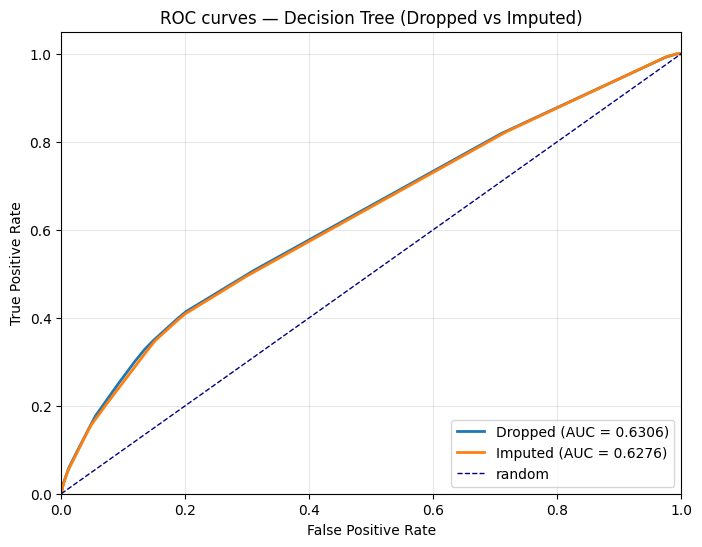

Dropped AUC: 0.6306
Imputed AUC: 0.6276


In [15]:
# Plot ROC AUC curves for decision tree models (dropped vs imputed)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
import joblib

def compute_roc(df, model=None, model_path=None, target='MADE_SHOT', test_size=0.3, random_state=42):
    # Recreate the same stratified split used for evaluation
    X = df.drop(columns=[target])
    y = df[target]
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    # Load model if not provided
    if model is None and model_path is not None:
        model = joblib.load(model_path)
    if model is None:
        raise ValueError('No model or model_path provided')
    # Get score/probabilities for positive class
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    fpr, tpr, thresholds = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    return dict(fpr=fpr, tpr=tpr, thresholds=thresholds, roc_auc=roc_auc, y_test=y_test, y_score=y_score)

# Try to use in-memory best models if available, otherwise fall back to saved files
candidates = [
    ('Dropped', globals().get('best_dt_model_dropped'), 'decision_tree_best_dropped.joblib', 'master_data_dropped_normalised'),
    ('Imputed', globals().get('best_dt_model_imputed'), 'decision_tree_best_imputed.joblib', 'master_data_imputed_normalised'),
]

plt.figure(figsize=(8,6))
results = {}
for label, model_obj, model_path, df_name in candidates:
    try:
        df = globals().get(df_name)
        use_model = model_obj if model_obj is not None else None
        use_path = model_path if (model_obj is None or not hasattr(model_obj, 'predict_proba')) else None
        res = compute_roc(df, model=use_model, model_path=use_path)
        results[label] = res
        plt.plot(res['fpr'], res['tpr'], lw=2, label=f"{label} (AUC = {res['roc_auc']:.4f})")
    except Exception as e:
        print(f"Skipping {label} ROC: {e}")

plt.plot([0,1], [0,1], color='navy', lw=1, linestyle='--', label='random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves — Decision Tree (Dropped vs Imputed)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# Optionally: print AUC numbers and return results for further use
for k, v in results.items():
    print(f"{k} AUC: {v['roc_auc']:.4f}")

### Random Forest

In [25]:

def _fit_random_forest_classifier(
        df,
        target,
        features_list,
        cv_folds=5,
        scoring="f1_weighted",
        n_iter=50,
        param_dist=None,
):
    """
    Fit a Random Forest classifier with hyperparameter tuning via RandomizedSearchCV.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The input dataframe containing features and target
    target : str
        Column name of the target variable
    features_list : list
        List of feature column names to use
    cv_folds : int
        Number of cross-validation folds (default: 5)
    scoring : str
        Primary scoring metric for model selection (default: 'f1_weighted')
    n_iter : int
        Number of parameter settings sampled in RandomizedSearchCV (default: 50)
    param_dist : dict
        Parameter distribution for RandomizedSearchCV. If None, uses defaults.
    
    Returns:
    --------
    best_model : RandomForestClassifier
        The best fitted random forest model
    """
    X = df[features_list]
    y = df[target]

    start_time = pd.Timestamp.now()

    if param_dist is None:
        # param_dist = {
        #     'n_estimators': [50, 100, 200, 300],
        #     'criterion': ['gini'],
        #     'max_depth': [None, 10, 20, 30, 50],
        #     'min_samples_split': [50, 100, 200, 500],
        #     'min_samples_leaf': [200, 500, 1000],
        #     'max_features': ['sqrt', 'log2', None],
        #     'max_leaf_nodes': [None, 10, 20, 50, 100],
        #     'min_impurity_decrease': [0.0, 1e-5, 1e-4, 1e-3],
        #     'bootstrap': [True, False]
        # }
        
        param_dist = {
            "n_estimators": [50, 100],               # smaller forest = MUCH faster
            "max_depth": [8, 12, 16],                # cap depth – prevents big trees
            "min_samples_split": [50, 100, 200],     # sensible for large datasets
            "min_samples_leaf": [50, 100, 200],      # keeps trees small
            "max_features": ["sqrt"],                # best default for RF
            "bootstrap": [True],                     # disable False (very expensive)
        }

    rf = RandomForestClassifier(random_state=42, n_jobs=-1)

    rs = RandomizedSearchCV(
        rf,
        param_distributions=param_dist,
        n_iter=n_iter,
        # scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
        scoring=['f1_weighted'],
        refit=scoring,
        cv=cv_folds,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    rs.fit(X, y)
    best_model = rs.best_estimator_

    print("Best Hyperparameters:", rs.best_params_)
    print(f"Best {scoring} (cv): {rs.best_score_:.4f}")

    # show top 5 candidates by chosen refit score
    results = pd.DataFrame(rs.cv_results_).sort_values(f'rank_test_{scoring}')
    display(results[[
        'params',
        f'mean_test_{scoring}',
        f'std_test_{scoring}',
        f'rank_test_{scoring}'
    ]].head())
    
    print("Time taken:", pd.Timestamp.now() - start_time)

    return best_model


def random_forest_classifier(df, target, features_list, cv_folds=5, scoring="f1_weighted", n_iter=50, param_dist=None):
    return _fit_random_forest_classifier(
        df=df,
        target=target,
        features_list=features_list,
        cv_folds=cv_folds,
        scoring=scoring,
        n_iter=n_iter,
        param_dist=param_dist,
    )


In [26]:
features_list_dropped = master_data_dropped_normalised.drop(columns=['MADE_SHOT']).columns.tolist()

features_list_imputed = master_data_imputed_normalised.drop(columns=['MADE_SHOT']).columns.tolist()

In [ ]:
best_rf_model_dropped = random_forest_classifier(
    df=master_data_dropped_normalised,
    target='MADE_SHOT',
    features_list=features_list_dropped,
    cv_folds=3,
    scoring='f1_weighted',
    n_iter=30
)

best_rf_model_imputed = random_forest_classifier(
    df=master_data_imputed_normalised,
    target='MADE_SHOT',
    features_list=features_list_imputed,
    cv_folds=3,
    scoring='f1_weighted',
    n_iter=30
)